In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

!pip install lightgbm
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import os
os.chdir('/content/drive/MyDrive/DSSI/Project/code')
import utils

np.random.seed(42)

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

print('All imports successful!')

Mounted at /content/drive
All imports successful!


In [12]:
aggregated_data = pd.read_csv('/content/drive/MyDrive/DSSI/Project/Valley Fever - Environmental/data_processed/aggregate/aggregate_all_counties_2001_2024.csv', parse_dates=['Year-Month'])
aggregated_data_trimmed = aggregated_data[(aggregated_data["Year-Month"] >= "2006-08") & (aggregated_data["Year-Month"] <= "2023-12")].copy()
aggregated_data_trimmed['log1p_rate_per_100k'] = np.log1p(aggregated_data_trimmed['rate_per_100k'])
aggregated_data_trimmed['duplicate_rate'] = aggregated_data_trimmed['rate_per_100k']

# imputed data
# aggregated_data = pd.read_csv('/content/drive/MyDrive/DSSI/Project/data/aggregate_all_counties_2001_2024_imputed.csv', parse_dates=['Year-Month'])
# aggregated_data['log1p_rate_per_100k'] = np.log1p(aggregated_data['rate_per_100k'])

# interpolating the NaN values in Tulare
cols = ['AQI_PM10', 'Avg Soil Temp (F)']

tulare_mask = aggregated_data_trimmed['County'] == "Tulare"

aggregated_data_trimmed.loc[tulare_mask, cols] = (
    aggregated_data_trimmed.loc[tulare_mask, cols]
    .apply(lambda s: s.interpolate(method="linear"))
)

In [9]:
def train_lightgbm_forecast(
        df,
        feature_cols,
        target_col="log1p_rate_per_100k",
        original_target_col="rate_per_100k",
        date_col="Year-Month",
        train_frac=0.80,
        n_estimators=1000,
        learning_rate=0.01,
        num_leaves=15,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=0.0,
        early_stopping_rounds=50,
        seed=42,
        verbose=True,
        plot=True,
        title="LightGBM Forecast"
):
    model_df = df.copy().sort_values(date_col).reset_index(drop=True)

    required_cols = list(feature_cols) + [
        target_col,
        original_target_col,
        date_col
    ]

    model_df = model_df[required_cols].dropna().reset_index(drop=True)

    split = int(train_frac * len(model_df))

    if split <= 0 or split >= len(model_df):
        raise ValueError("The split must leave both training and test observations.")

    X = model_df[feature_cols]
    y = model_df[target_col]

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    dates_train = pd.to_datetime(model_df[date_col].iloc[:split])
    dates_test = pd.to_datetime(model_df[date_col].iloc[split:])

    actual_train_rate = model_df[original_target_col].iloc[:split].to_numpy()
    actual_test_rate = model_df[original_target_col].iloc[split:].to_numpy()

    model = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        max_depth=max_depth,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=seed,
        n_jobs=-1,
        verbosity=-1
    )

    callbacks = []

    if early_stopping_rounds is not None:
        callbacks.append(
            lgb.early_stopping(
                stopping_rounds=early_stopping_rounds,
                verbose=verbose
            )
        )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="rmse",
        callbacks=callbacks
    )

    train_predicted_log = model.predict(X_train, num_iteration=model.best_iteration_)

    test_predicted_log = model.predict(X_test, num_iteration=model.best_iteration_)

    train_predicted_rate = np.expm1(train_predicted_log)
    test_predicted_rate = np.expm1(test_predicted_log)

    train_log_rmse = np.sqrt(mean_squared_error(y_train, train_predicted_log))

    train_log_mae = mean_absolute_error(y_train, train_predicted_log)

    train_log_r2 = r2_score(y_train, train_predicted_log)

    test_log_rmse = np.sqrt(mean_squared_error(y_test, test_predicted_log))

    test_log_mae = mean_absolute_error(y_test, test_predicted_log)

    test_log_r2 = r2_score(y_test, test_predicted_log)

    train_rmse = np.sqrt(mean_squared_error(actual_train_rate, train_predicted_rate))

    train_mae = mean_absolute_error(actual_train_rate, train_predicted_rate)

    train_r2 = r2_score(actual_train_rate, train_predicted_rate)

    test_rmse = np.sqrt(mean_squared_error(actual_test_rate, test_predicted_rate))

    test_mae = mean_absolute_error(actual_test_rate, test_predicted_rate)

    test_r2 = r2_score(actual_test_rate, test_predicted_rate)

    if verbose:
        print(f"Training observations: {len(X_train)}")
        print(f"Test observations: {len(X_test)}")
        print(f"Best iteration: {model.best_iteration_}")

        print()
        print("Logged target metrics")
        print(f"Train RMSE: {train_log_rmse:.4f}")
        print(f"Train MAE:  {train_log_mae:.4f}")
        print(f"Train R²:   {train_log_r2:.4f}")
        print(f"Test RMSE:  {test_log_rmse:.4f}")
        print(f"Test MAE:   {test_log_mae:.4f}")
        print(f"Test R²:    {test_log_r2:.4f}")

        print()
        print("Original rate metrics")
        print(f"Train RMSE: {train_rmse:.4f}")
        print(f"Train MAE:  {train_mae:.4f}")
        print(f"Train R²:   {train_r2:.4f}")
        print(f"Test RMSE:  {test_rmse:.4f}")
        print(f"Test MAE:   {test_mae:.4f}")
        print(f"Test R²:    {test_r2:.4f}")

    train_results = pd.DataFrame({
        date_col: dates_train.to_numpy(),
        "Actual_Log1p_Rate": y_train.to_numpy(),
        "Predicted_Log1p_Rate": train_predicted_log,
        "Actual_Rate": actual_train_rate,
        "Predicted_Rate": train_predicted_rate,
        "Dataset": "Train"
    })

    test_results = pd.DataFrame({
        date_col: dates_test.to_numpy(),
        "Actual_Log1p_Rate": y_test.to_numpy(),
        "Predicted_Log1p_Rate": test_predicted_log,
        "Actual_Rate": actual_test_rate,
        "Predicted_Rate": test_predicted_rate,
        "Dataset": "Test"
    })

    results = pd.concat(
        [train_results, test_results],
        ignore_index=True
    )

    feature_importance = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": model.feature_importances_
    }).sort_values(
        "Importance",
        ascending=False
    ).reset_index(drop=True)

    if plot:
        fig, ax = plt.subplots(figsize=(14, 6))

        ax.plot(
            results[date_col],
            results["Actual_Rate"],
            label="Actual",
            linewidth=2
        )

        ax.plot(
            train_results[date_col],
            train_results["Predicted_Rate"],
            label="Training Prediction",
            linestyle="--"
        )

        ax.plot(
            test_results[date_col],
            test_results["Predicted_Rate"],
            label="Test Prediction",
            linestyle="--"
        )

        ax.axvline(
            test_results[date_col].iloc[0],
            linestyle=":",
            label="Train/Test Split"
        )

        ax.set_title(title)
        ax.set_xlabel("Month")
        ax.set_ylabel("Rate per 100,000")
        ax.grid(True, alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.show()

    return {
        "model": model,
        "results": results,
        "train_results": train_results,
        "test_results": test_results,
        "feature_importance": feature_importance,
        "feature_names": list(feature_cols),
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "train_log_rmse": train_log_rmse,
        "train_log_mae": train_log_mae,
        "train_log_r2": train_log_r2,
        "test_log_rmse": test_log_rmse,
        "test_log_mae": test_log_mae,
        "test_log_r2": test_log_r2,
        "train_rmse": train_rmse,
        "train_mae": train_mae,
        "train_r2": train_r2,
        "rmse": test_rmse,
        "mae": test_mae,
        "r2": test_r2,
        "best_iteration": model.best_iteration_
    }

# All features

In [ ]:
features_by_county = {
    "Fresno": [
        "Precipitation",
        "Avg Rel Hum (%)",
        "Avg Wind Speed (mph)",
        "Wind Run (miles)",
        "windeventcount",
        "Avg Soil Temp (F)",
        "AQI_PM25",
        "AQI_PM10",
        "FIRE_Acres_Burned",
        "fungicide_lbs_prd_used",
        "rodent_lbs_prd_used"
    ],
    "Kern": [
        "Precipitation",
        "Avg Rel Hum (%)",
        "Avg Wind Speed (mph)",
        "Wind Run (miles)",
        "windeventcount",
        "Avg Soil Temp (F)",
        "AQI_PM25",
        "AQI_PM10",
        "FIRE_Acres_Burned",
        "fungicide_lbs_prd_used",
        "rodent_lbs_prd_used"
    ],
    "Los Angeles": [
        "Precipitation",
        "Avg Rel Hum (%)",
        "Avg Wind Speed (mph)",
        "Wind Run (miles)",
        "windeventcount",
        "Avg Soil Temp (F)",
        "AQI_PM25",
        "AQI_PM10",
        "FIRE_Acres_Burned",
        "fungicide_lbs_prd_used",
        "rodent_lbs_prd_used"
    ],
    "Orange": [
        "Precipitation",
        "Avg Rel Hum (%)",
        "Avg Wind Speed (mph)",
        "Wind Run (miles)",
        "windeventcount",
        "Avg Soil Temp (F)",
        "AQI_PM25",
        "AQI_PM10",
        "FIRE_Acres_Burned",
        "fungicide_lbs_prd_used",
        "rodent_lbs_prd_used"
    ],
    "San Diego": [
        "Precipitation",
        "Avg Rel Hum (%)",
        "Avg Wind Speed (mph)",
        "Wind Run (miles)",
        "windeventcount",
        "Avg Soil Temp (F)",
        "AQI_PM25",
        "AQI_PM10",
        "FIRE_Acres_Burned",
        "fungicide_lbs_prd_used",
        "rodent_lbs_prd_used"
    ],
    "San Luis Obispo": [
        "Precipitation",
        "Avg Rel Hum (%)",
        "Avg Wind Speed (mph)",
        "Wind Run (miles)",
        "windeventcount",
        "Avg Soil Temp (F)",
        "AQI_PM25",
        "AQI_PM10",
        "FIRE_Acres_Burned",
        "fungicide_lbs_prd_used",
        "rodent_lbs_prd_used"
    ],
    "Tulare": [
        "Precipitation",
        "Avg Rel Hum (%)",
        "Avg Wind Speed (mph)",
        "Wind Run (miles)",
        "windeventcount",
        "Avg Soil Temp (F)",
        "AQI_PM25",
        "AQI_PM10",
        "FIRE_Acres_Burned",
        "fungicide_lbs_prd_used",
        "rodent_lbs_prd_used"
    ],
    "Ventura": [
        "Precipitation",
        "Avg Rel Hum (%)",
        "Avg Wind Speed (mph)",
        "Wind Run (miles)",
        "windeventcount",
        "Avg Soil Temp (F)",
        "AQI_PM25",
        "AQI_PM10",
        "FIRE_Acres_Burned",
        "fungicide_lbs_prd_used",
        "rodent_lbs_prd_used"
    ]
}


Running Fresno...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[64]	valid_0's rmse: 0.244719	valid_0's l2: 0.0598875
Training observations: 167
Test observations: 42
Best iteration: 64

Logged target metrics
Train RMSE: 0.4298
Train MAE:  0.3588
Train R²:   0.1932
Test RMSE:  0.2447
Test MAE:   0.1843
Test R²:    0.0630

Original rate metrics
Train RMSE: 2.5592
Train MAE:  1.9127
Train R²:   0.1393
Test RMSE:  1.5085
Test MAE:   0.9657
Test R²:    0.0570


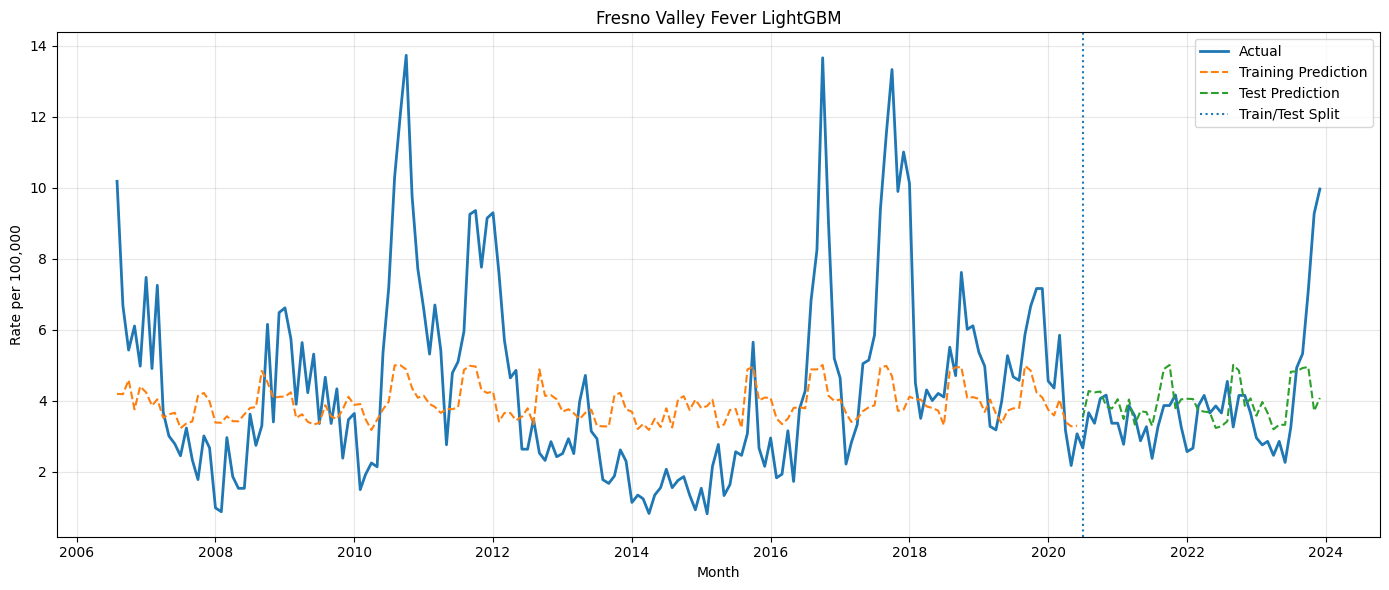


Running Kern...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[129]	valid_0's rmse: 0.450202	valid_0's l2: 0.202682
Training observations: 167
Test observations: 42
Best iteration: 129

Logged target metrics
Train RMSE: 0.5002
Train MAE:  0.4112
Train R²:   0.2630
Test RMSE:  0.4502
Test MAE:   0.3735
Test R²:    -2.4450

Original rate metrics
Train RMSE: 9.8813
Train MAE:  7.3257
Train R²:   0.1799
Test RMSE:  11.3317
Test MAE:   8.5840
Test R²:    -1.3734


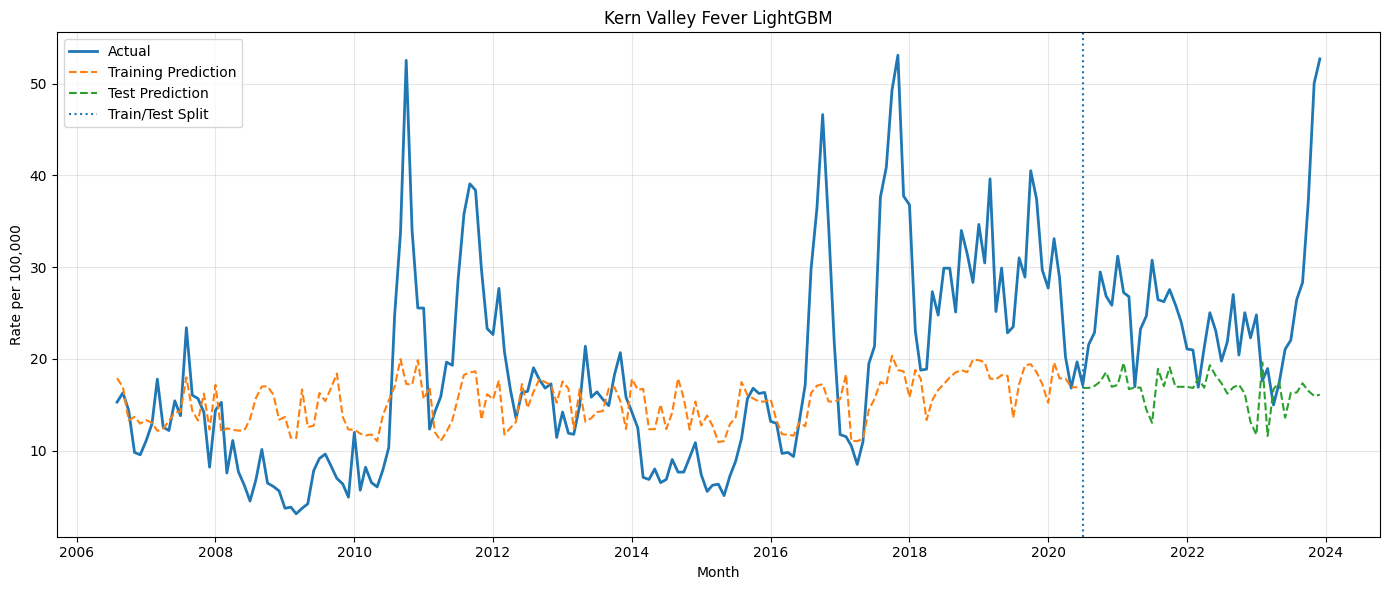


Running Los Angeles...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.457202	valid_0's l2: 0.209034
Training observations: 167
Test observations: 42
Best iteration: 1

Logged target metrics
Train RMSE: 0.1893
Train MAE:  0.1596
Train R²:   0.0039
Test RMSE:  0.4572
Test MAE:   0.4499
Test R²:    -30.5012

Original rate metrics
Train RMSE: 0.2906
Train MAE:  0.2328
Train R²:   -0.0049
Test RMSE:  0.8245
Test MAE:   0.8042
Test R²:    -19.5092


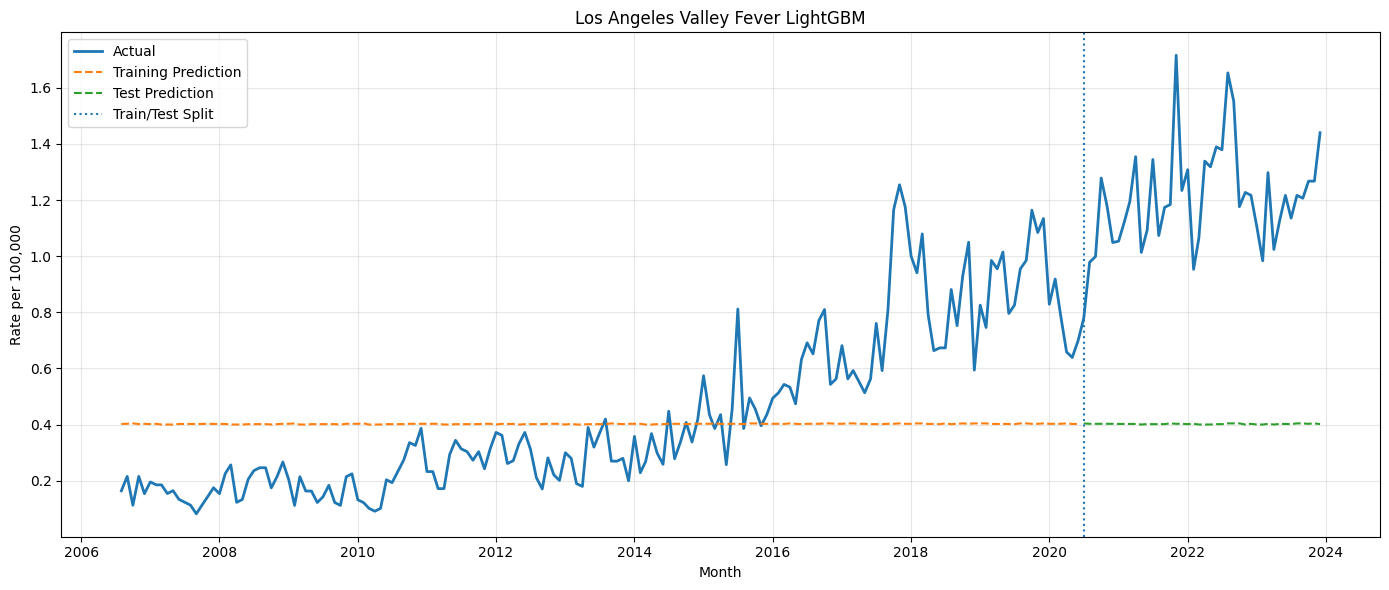


Running Orange...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[700]	valid_0's rmse: 0.181092	valid_0's l2: 0.0327944
Training observations: 167
Test observations: 42
Best iteration: 700

Logged target metrics
Train RMSE: 0.0826
Train MAE:  0.0653
Train R²:   0.7540
Test RMSE:  0.1811
Test MAE:   0.1486
Test R²:    -2.6145

Original rate metrics
Train RMSE: 0.1200
Train MAE:  0.0892
Train R²:   0.7405
Test RMSE:  0.3081
Test MAE:   0.2504
Test R²:    -2.2892


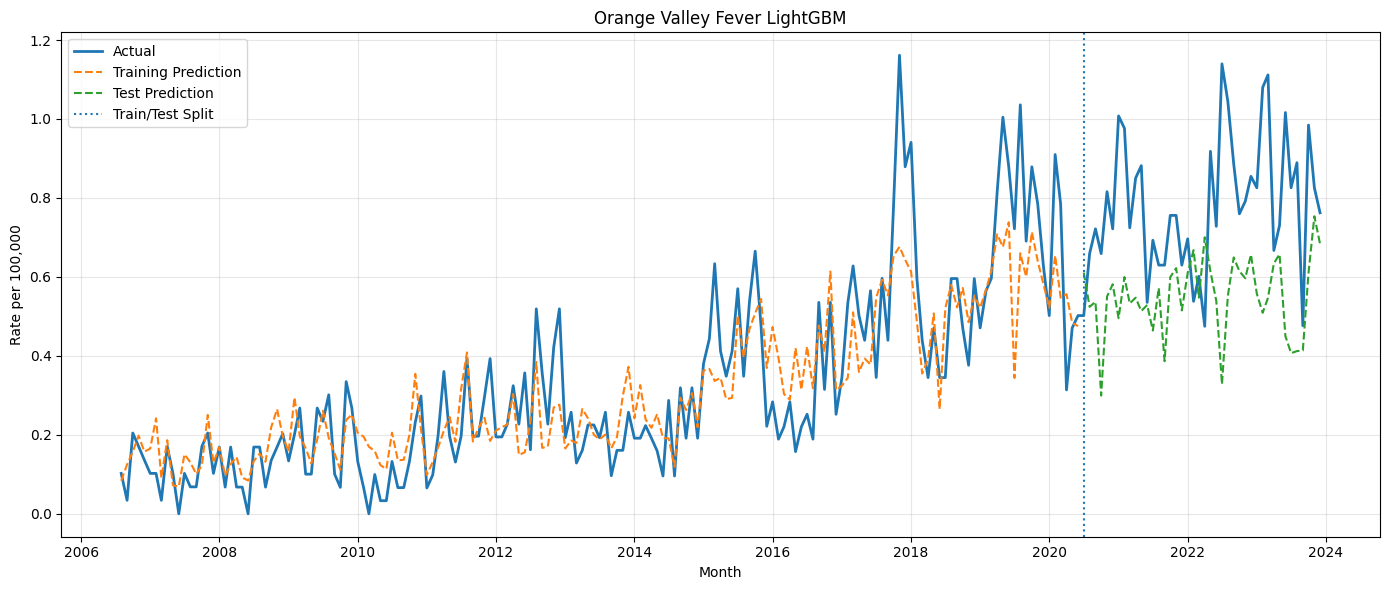


Running San Diego...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[700]	valid_0's rmse: 0.328317	valid_0's l2: 0.107792
Training observations: 167
Test observations: 42
Best iteration: 700

Logged target metrics
Train RMSE: 0.1088
Train MAE:  0.0824
Train R²:   0.6894
Test RMSE:  0.3283
Test MAE:   0.2969
Test R²:    -9.7687

Original rate metrics
Train RMSE: 0.1826
Train MAE:  0.1268
Train R²:   0.6694
Test RMSE:  0.5997
Test MAE:   0.5416
Test R²:    -7.4929


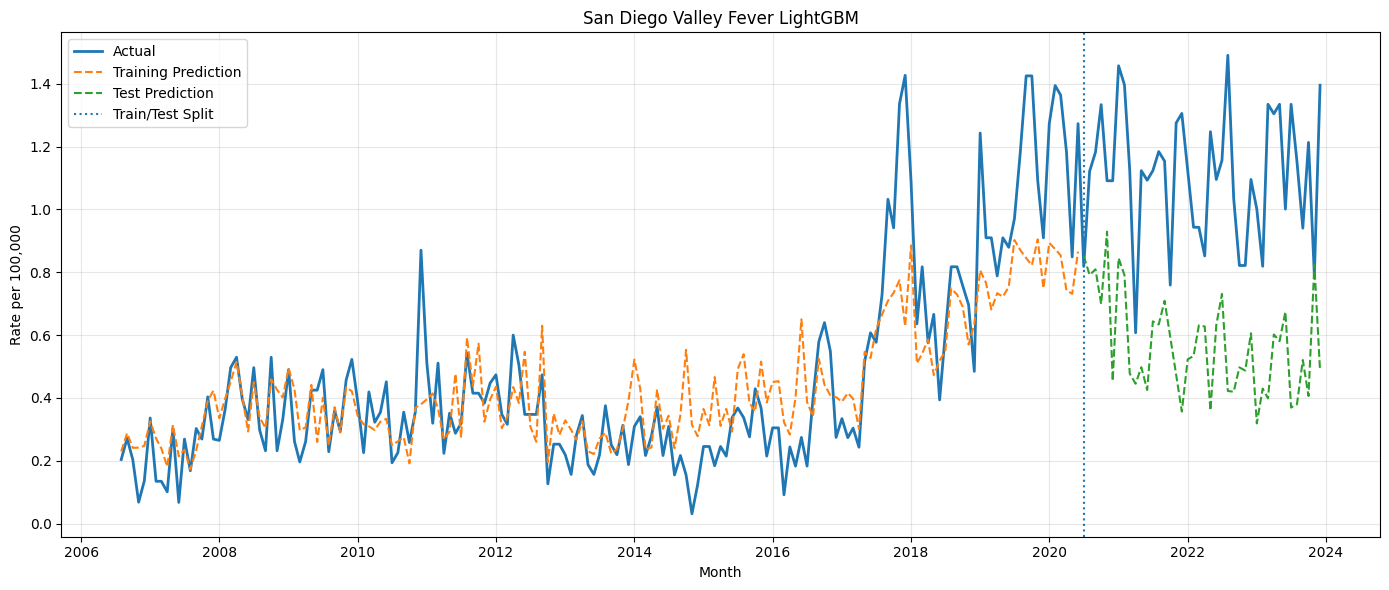


Running San Luis Obispo...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[289]	valid_0's rmse: 0.424049	valid_0's l2: 0.179817
Training observations: 167
Test observations: 42
Best iteration: 289

Logged target metrics
Train RMSE: 0.5358
Train MAE:  0.4015
Train R²:   0.4707
Test RMSE:  0.4240
Test MAE:   0.3264
Test R²:    0.0761

Original rate metrics
Train RMSE: 4.7468
Train MAE:  2.4411
Train R²:   0.2669
Test RMSE:  4.0220
Test MAE:   2.2602
Test R²:    0.1855


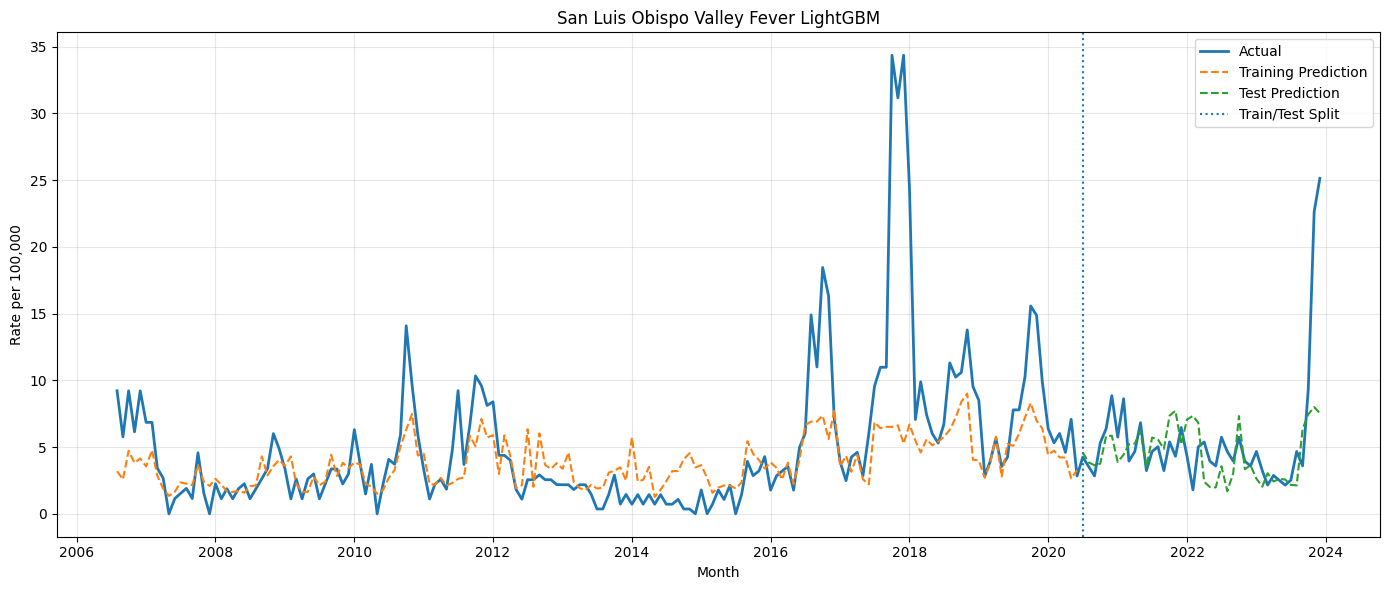


Running Tulare...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[615]	valid_0's rmse: 0.43601	valid_0's l2: 0.190105
Training observations: 167
Test observations: 42
Best iteration: 615

Logged target metrics
Train RMSE: 0.2958
Train MAE:  0.2413
Train R²:   0.5765
Test RMSE:  0.4360
Test MAE:   0.3650
Test R²:    -0.6117

Original rate metrics
Train RMSE: 1.6424
Train MAE:  1.1807
Train R²:   0.4921
Test RMSE:  3.3211
Test MAE:   2.3754
Test R²:    -0.2220


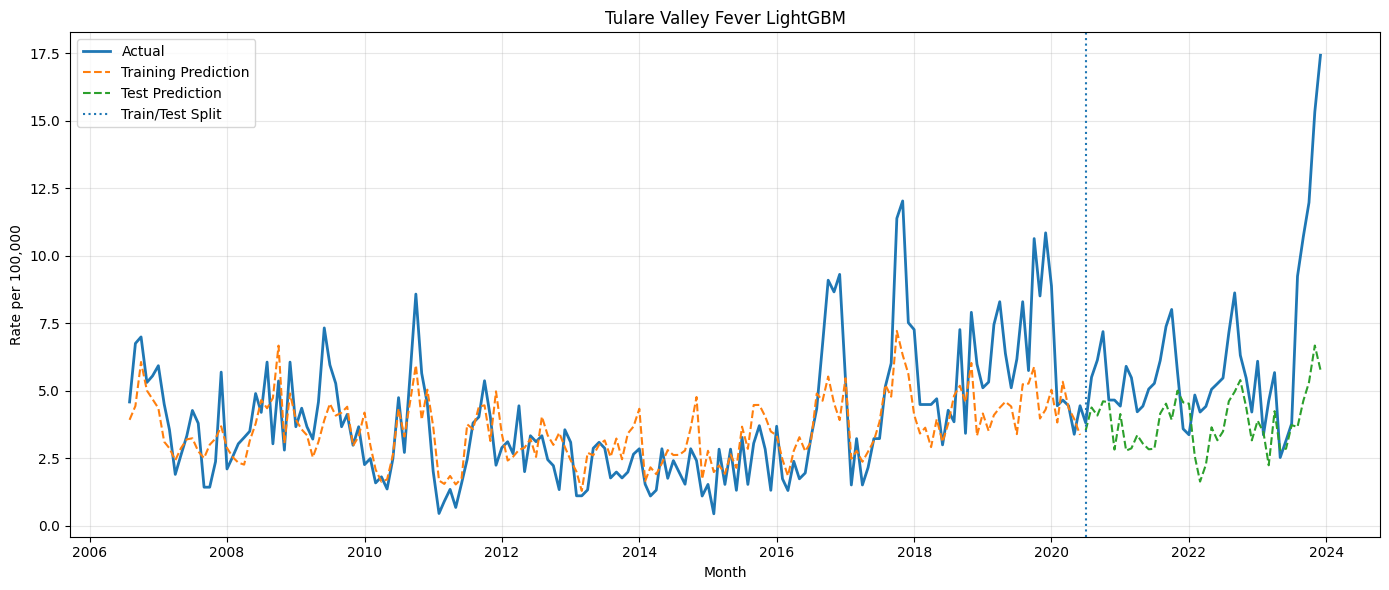


Running Ventura...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[134]	valid_0's rmse: 0.627271	valid_0's l2: 0.393469
Training observations: 167
Test observations: 42
Best iteration: 134

Logged target metrics
Train RMSE: 0.4198
Train MAE:  0.3171
Train R²:   0.2474
Test RMSE:  0.6273
Test MAE:   0.5626
Test R²:    -3.2754

Original rate metrics
Train RMSE: 1.3020
Train MAE:  0.7452
Train R²:   0.1277
Test RMSE:  1.8805
Test MAE:   1.5733
Test R²:    -2.0046


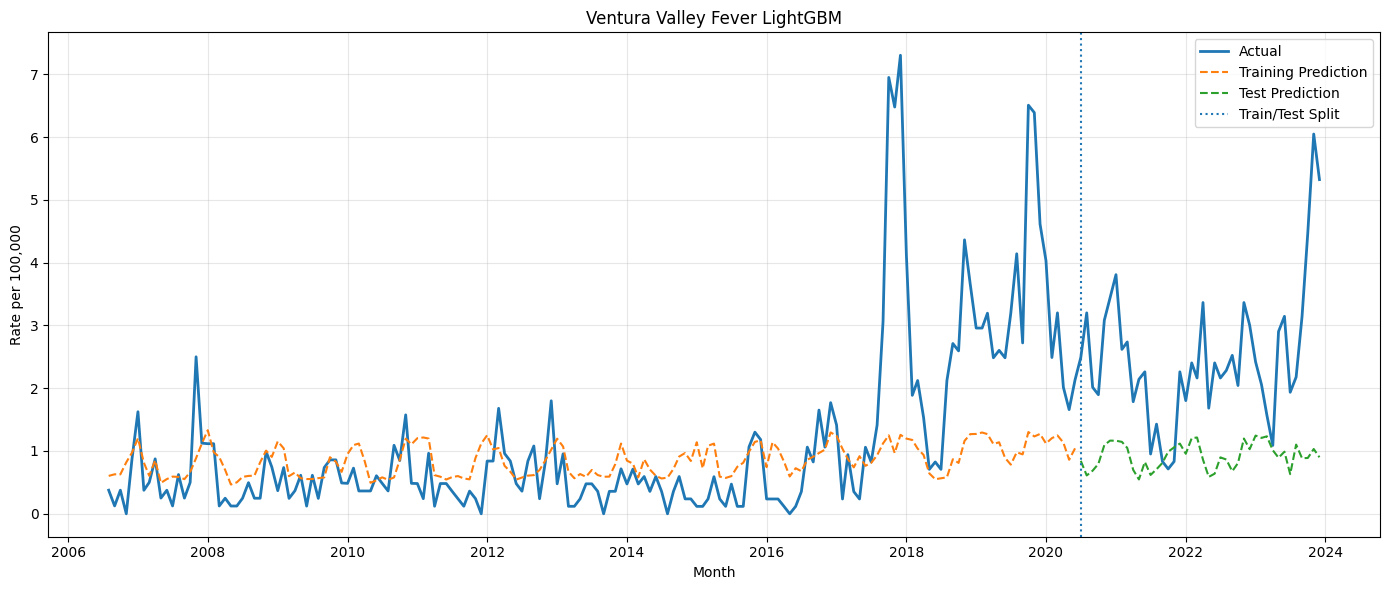

,County,Number_Features,Best_Iteration,Train_Log_RMSE,Test_Log_RMSE,Train_RMSE,Train_MAE,Train_R2,Test_RMSE,Test_MAE,Test_R2,Features
0,Orange,11,700,0.082604,0.181092,0.119968,0.089189,0.740506,0.308112,0.250357,-2.289196,"[Precipitation, Avg Rel Hum (%), Avg Wind Spee..."
1,San Diego,11,700,0.108800,0.328317,0.182610,0.126765,0.669383,0.599711,0.541590,-7.492910,"[Precipitation, Avg Rel Hum (%), Avg Wind Spee..."
2,Los Angeles,11,1,0.189334,0.457202,0.290558,0.232841,-0.004912,0.824488,0.804181,-19.509165,"[Precipitation, Avg Rel Hum (%), Avg Wind Spee..."
3,Fresno,11,64,0.429791,0.244719,2.559176,1.912723,0.139342,1.508528,0.965748,0.057032,"[Precipitation, Avg Rel Hum (%), Avg Wind Spee..."
4,Ventura,11,134,0.419794,0.627271,1.302045,0.745194,0.127672,1.880537,1.573282,-2.004584,"[Precipitation, Avg Rel Hum (%), Avg Wind Spee..."
5,Tulare,11,615,0.295831,0.436010,1.642385,1.180724,0.492143,3.321112,2.375405,-0.221991,"[Precipitation, Avg Rel Hum (%), Avg Wind Spee..."
6,San Luis Obispo,11,289,0.535753,0.424049,4.746767,2.441121,0.266875,4.022004,2.260239,0.185525,"[Precipitation, Avg Rel Hum (%), Avg Wind Spee..."
7,Kern,11,129,0.500194,0.450202,9.881299,7.325664,0.179881,11.331672,8.583999,-1.373372,"[Precipitation, Avg Rel Hum (%), Avg Wind Spee..."


In [ ]:
all_county_lightgbm_results = {}
all_county_lightgbm_metrics = []

for county, feature_cols in features_by_county.items():
    print(f"\nRunning {county}...")

    county_df = (
        aggregated_data_trimmed[
            aggregated_data_trimmed["County"] == county
        ]
        .copy()
        .sort_values("Year-Month")
        .reset_index(drop=True)
    )

    county_results = train_lightgbm_forecast(
        df=county_df,
        feature_cols=feature_cols,
        target_col="log1p_rate_per_100k",
        original_target_col="rate_per_100k",
        date_col="Year-Month",
        train_frac=0.80,
        n_estimators=700,
        learning_rate=0.01,
        num_leaves=7,
        max_depth=3,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        seed=42,
        verbose=True,
        plot=True,
        title=f"{county} Valley Fever LightGBM"
    )

    all_county_lightgbm_results[county] = county_results

    all_county_lightgbm_metrics.append({
        "County": county,
        "Number_Features": len(feature_cols),
        "Best_Iteration": county_results["best_iteration"],
        "Train_Log_RMSE": county_results["train_log_rmse"],
        "Test_Log_RMSE": county_results["test_log_rmse"],
        "Train_RMSE": county_results["train_rmse"],
        "Train_MAE": county_results["train_mae"],
        "Train_R2": county_results["train_r2"],
        "Test_RMSE": county_results["rmse"],
        "Test_MAE": county_results["mae"],
        "Test_R2": county_results["r2"],
        "Features": feature_cols
    })

all_county_lightgbm_metrics_df = pd.DataFrame(
    all_county_lightgbm_metrics
)

display(
    all_county_lightgbm_metrics_df
    .sort_values("Test_RMSE")
    .reset_index(drop=True)
)

# using best features according to feature combinations

In [10]:
features_by_county = {
    "Fresno": [
        # "Precipitation",
        # "Avg Rel Hum (%)",
        # "Avg Wind Speed (mph)",
        "Wind Run (miles)",
        "windeventcount",
        "Avg Soil Temp (F)",
        # "AQI_PM25",
        "AQI_PM10",
        # "FIRE_Acres_Burned",
        "fungicide_lbs_prd_used",
        # "rodent_lbs_prd_used"
    ],
    "Kern": [
        # "Precipitation",
        "Avg Rel Hum (%)",
        # "Avg Wind Speed (mph)",
        # "Wind Run (miles)",
        # "windeventcount",
        "Avg Soil Temp (F)",
        # "AQI_PM25",
        # "AQI_PM10",
        # "FIRE_Acres_Burned",
        "fungicide_lbs_prd_used",
        # "rodent_lbs_prd_used"
    ],
    "Los Angeles": [
        "Precipitation",
        # "Avg Rel Hum (%)",
        "Avg Wind Speed (mph)",
        # "Wind Run (miles)",
        # "windeventcount",
        # "Avg Soil Temp (F)",
        # "AQI_PM25",
        "AQI_PM10",
        # "FIRE_Acres_Burned",
        # "fungicide_lbs_prd_used",
        # "rodent_lbs_prd_used"
    ],
    "Orange": [
        # "Precipitation",
        # "Avg Rel Hum (%)",
        # "Avg Wind Speed (mph)",
        # "Wind Run (miles)",
        "windeventcount",
        "Avg Soil Temp (F)",
        # "AQI_PM25",
        # "AQI_PM10",
        "FIRE_Acres_Burned",
        # "fungicide_lbs_prd_used",
        "rodent_lbs_prd_used"
    ],
    "San Diego": [
        # "Precipitation",
        # "Avg Rel Hum (%)",
        # "Avg Wind Speed (mph)",
        # "Wind Run (miles)",
        "windeventcount",
        "Avg Soil Temp (F)",
        # "AQI_PM25",
        "AQI_PM10",
        # "FIRE_Acres_Burned",
        "fungicide_lbs_prd_used",
        # "rodent_lbs_prd_used"
    ],
    "San Luis Obispo": [
        # "Precipitation",
        "Avg Rel Hum (%)",
        # "Avg Wind Speed (mph)",
        # "Wind Run (miles)",
        "windeventcount",
        "Avg Soil Temp (F)",
        # "AQI_PM25",
        # "AQI_PM10",
        # "FIRE_Acres_Burned",
        "fungicide_lbs_prd_used",
        # "rodent_lbs_prd_used"
    ],
    "Tulare": [
        "Precipitation",
        # "Avg Rel Hum (%)",
        "Avg Wind Speed (mph)",
        # "Wind Run (miles)",
        "windeventcount",
        "Avg Soil Temp (F)",
        # "AQI_PM25",
        # "AQI_PM10",
        # "FIRE_Acres_Burned",
        # "fungicide_lbs_prd_used",
        # "rodent_lbs_prd_used"
    ],
    "Ventura": [
        # "Precipitation",
        "Avg Rel Hum (%)",
        # "Avg Wind Speed (mph)",
        # "Wind Run (miles)",
        # "windeventcount",
        # "Avg Soil Temp (F)",
        # "AQI_PM25",
        "AQI_PM10",
        "FIRE_Acres_Burned",
        # "fungicide_lbs_prd_used",
        # "rodent_lbs_prd_used"
    ]
}


Running Fresno...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[4]	valid_0's rmse: 0.254164	valid_0's l2: 0.0645992
Training observations: 167
Test observations: 42
Best iteration: 4

Logged target metrics
Train RMSE: 0.4584
Train MAE:  0.3825
Train R²:   0.0821
Test RMSE:  0.2542
Test MAE:   0.1867
Test R²:    -0.0107

Original rate metrics
Train RMSE: 3.9884
Train MAE:  2.9606
Train R²:   -1.0904
Test RMSE:  2.7471
Test MAE:   2.2685
Test R²:    -2.1272


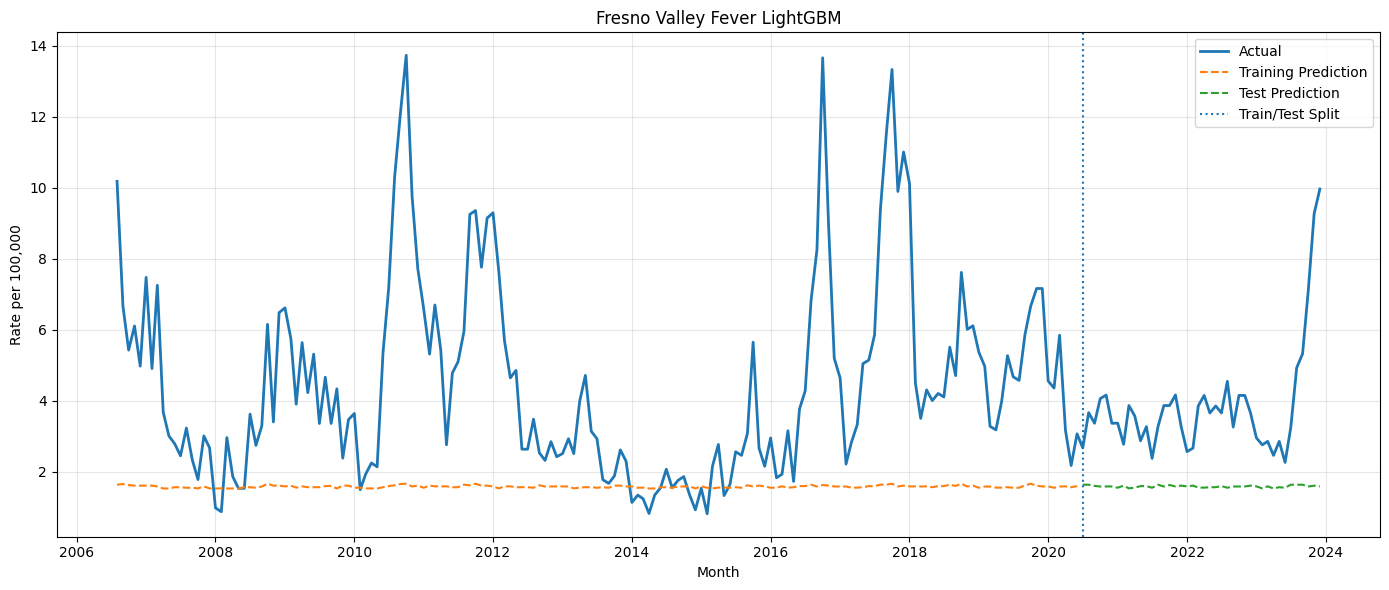


Running Kern...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[95]	valid_0's rmse: 0.425547	valid_0's l2: 0.18109
Training observations: 167
Test observations: 42
Best iteration: 95

Logged target metrics
Train RMSE: 0.4243
Train MAE:  0.3548
Train R²:   0.4698
Test RMSE:  0.4255
Test MAE:   0.3467
Test R²:    -2.0780

Original rate metrics
Train RMSE: 18.5730
Train MAE:  15.1627
Train R²:   -1.8974
Test RMSE:  23.2900
Test MAE:   22.1249
Test R²:    -9.0257


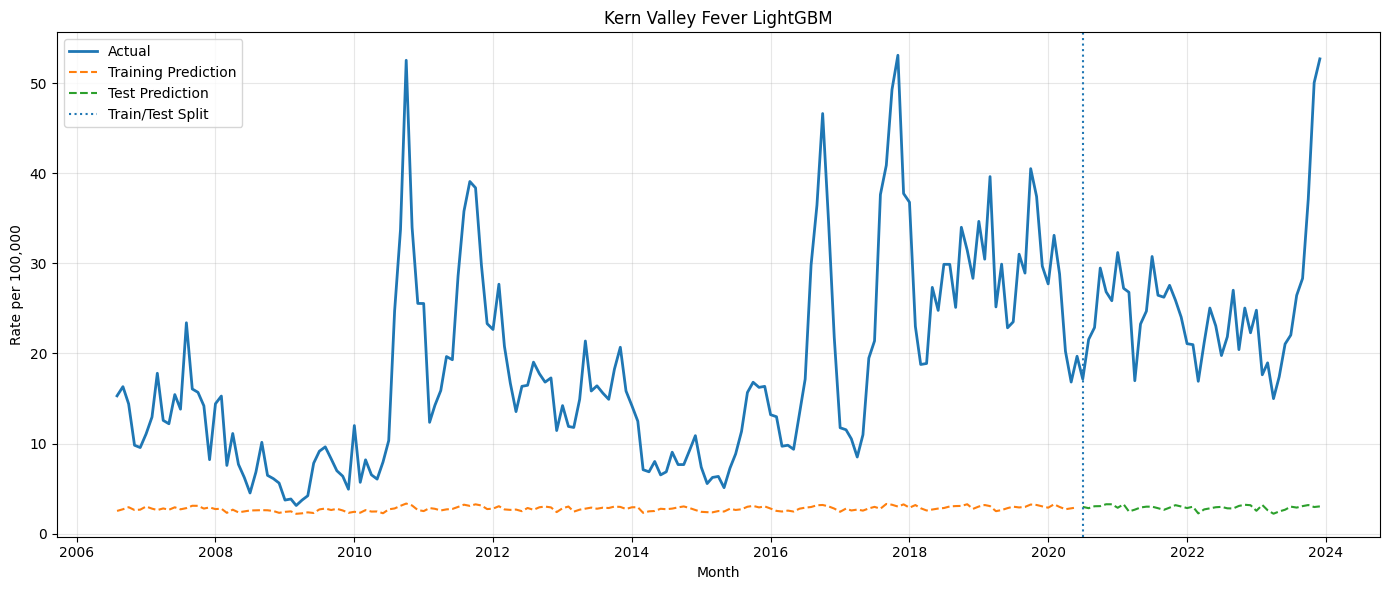


Running Los Angeles...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.457764	valid_0's l2: 0.209548
Training observations: 167
Test observations: 42
Best iteration: 1

Logged target metrics
Train RMSE: 0.1880
Train MAE:  0.1583
Train R²:   0.0183
Test RMSE:  0.4578
Test MAE:   0.4505
Test R²:    -30.5786

Original rate metrics
Train RMSE: 0.3021
Train MAE:  0.2235
Train R²:   -0.0866
Test RMSE:  0.8878
Test MAE:   0.8690
Test R²:    -22.7802


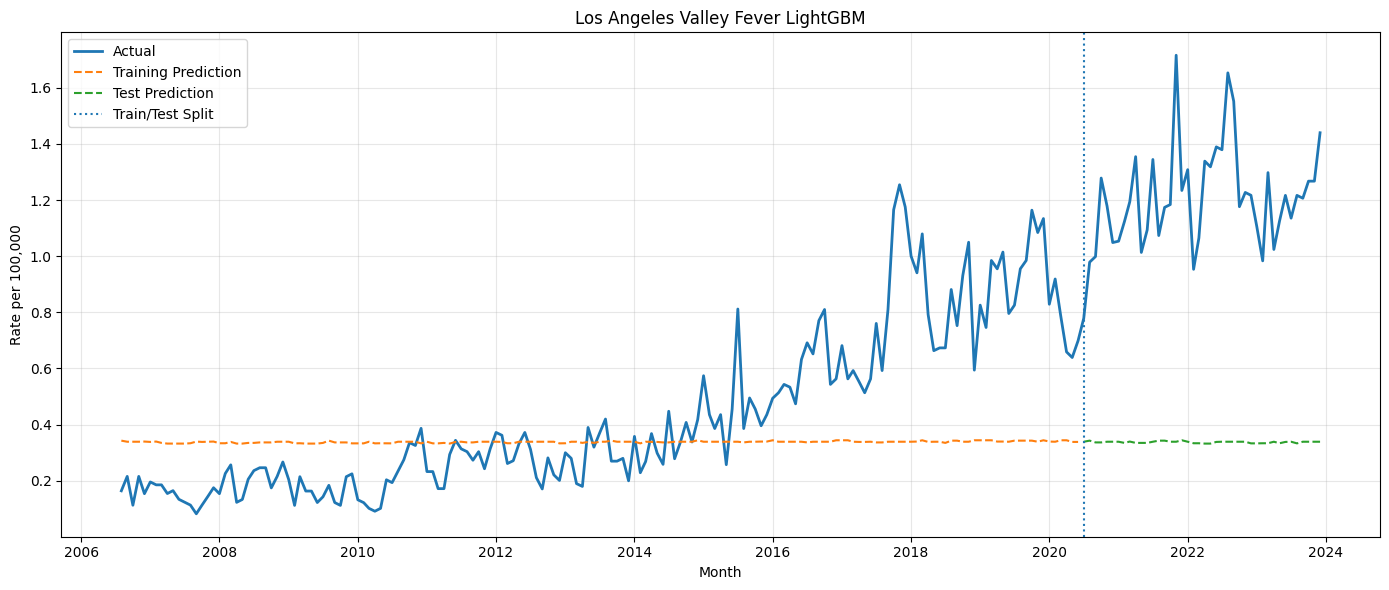


Running Orange...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[90]	valid_0's rmse: 0.194187	valid_0's l2: 0.0377085
Training observations: 167
Test observations: 42
Best iteration: 90

Logged target metrics
Train RMSE: 0.0900
Train MAE:  0.0704
Train R²:   0.7082
Test RMSE:  0.1942
Test MAE:   0.1540
Test R²:    -3.1561

Original rate metrics
Train RMSE: 0.1597
Train MAE:  0.1123
Train R²:   0.5401
Test RMSE:  0.3924
Test MAE:   0.3357
Test R²:    -4.3351


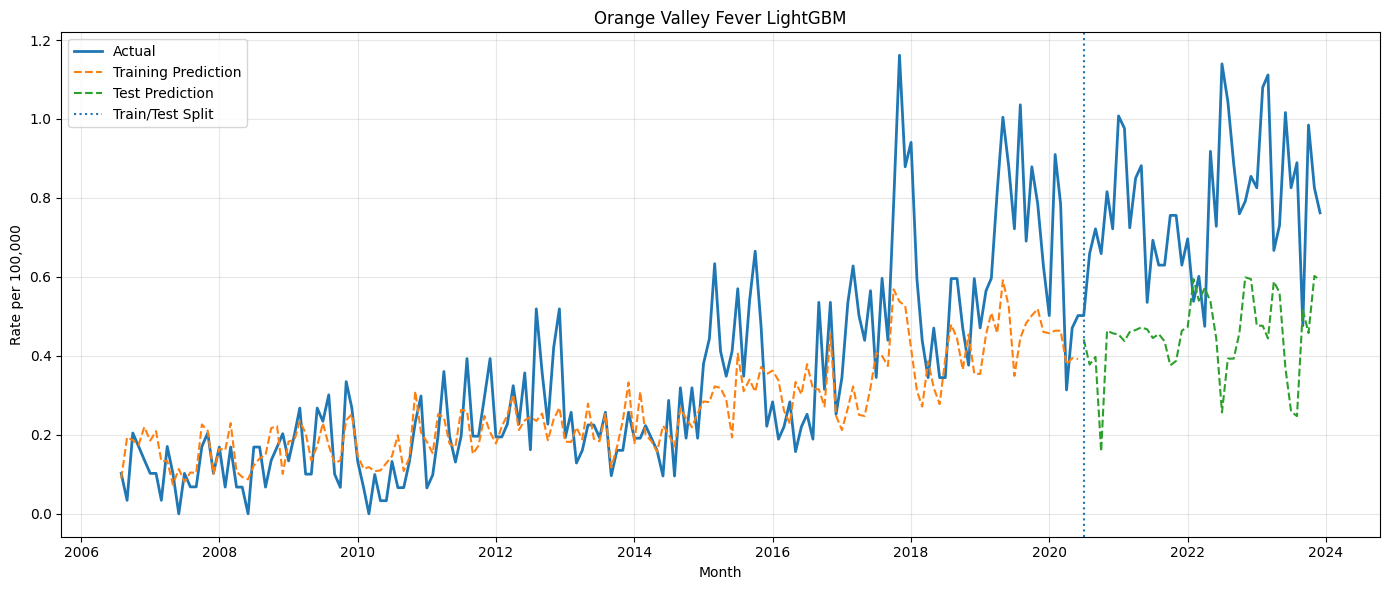


Running San Diego...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[141]	valid_0's rmse: 0.381382	valid_0's l2: 0.145452
Training observations: 167
Test observations: 42
Best iteration: 141

Logged target metrics
Train RMSE: 0.1210
Train MAE:  0.0899
Train R²:   0.6157
Test RMSE:  0.3814
Test MAE:   0.3468
Test R²:    -13.5311

Original rate metrics
Train RMSE: 0.2569
Train MAE:  0.1630
Train R²:   0.3455
Test RMSE:  0.7550
Test MAE:   0.7135
Test R²:    -12.4606


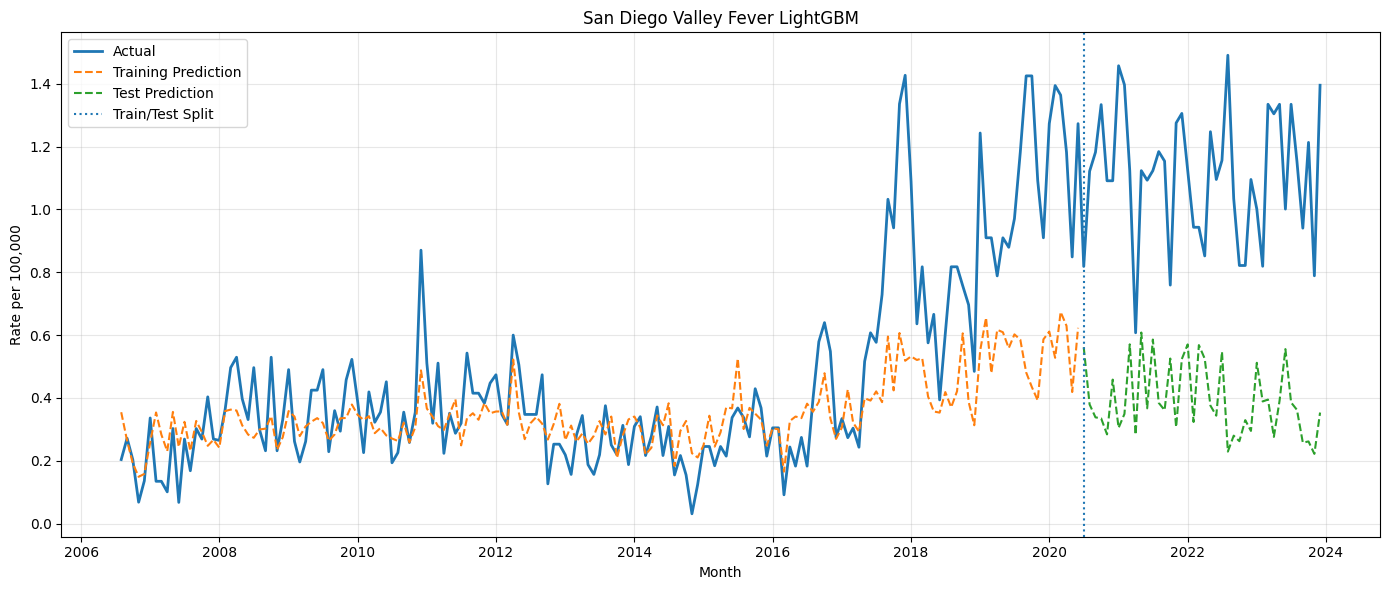


Running San Luis Obispo...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[27]	valid_0's rmse: 0.451746	valid_0's l2: 0.204074
Training observations: 167
Test observations: 42
Best iteration: 27

Logged target metrics
Train RMSE: 0.6173
Train MAE:  0.4972
Train R²:   0.2973
Test RMSE:  0.4517
Test MAE:   0.3143
Test R²:    -0.0485

Original rate metrics
Train RMSE: 6.4705
Train MAE:  3.7707
Train R²:   -0.3623
Test RMSE:  5.8912
Test MAE:   3.9201
Test R²:    -0.7474


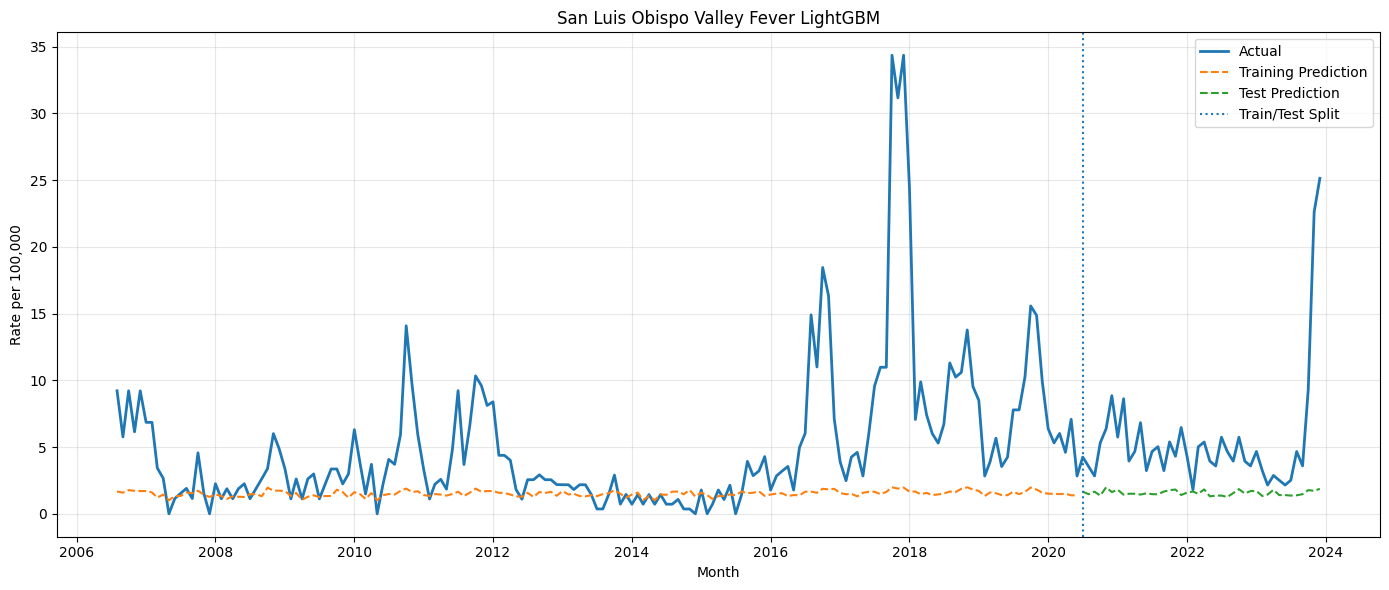


Running Tulare...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[19]	valid_0's rmse: 0.500998	valid_0's l2: 0.250999
Training observations: 167
Test observations: 42
Best iteration: 19

Logged target metrics
Train RMSE: 0.3969
Train MAE:  0.3239
Train R²:   0.2378
Test RMSE:  0.5010
Test MAE:   0.4076
Test R²:    -1.1279

Original rate metrics
Train RMSE: 3.2816
Train MAE:  2.4454
Train R²:   -1.0275
Test RMSE:  5.4615
Test MAE:   4.5882
Test R²:    -2.3046


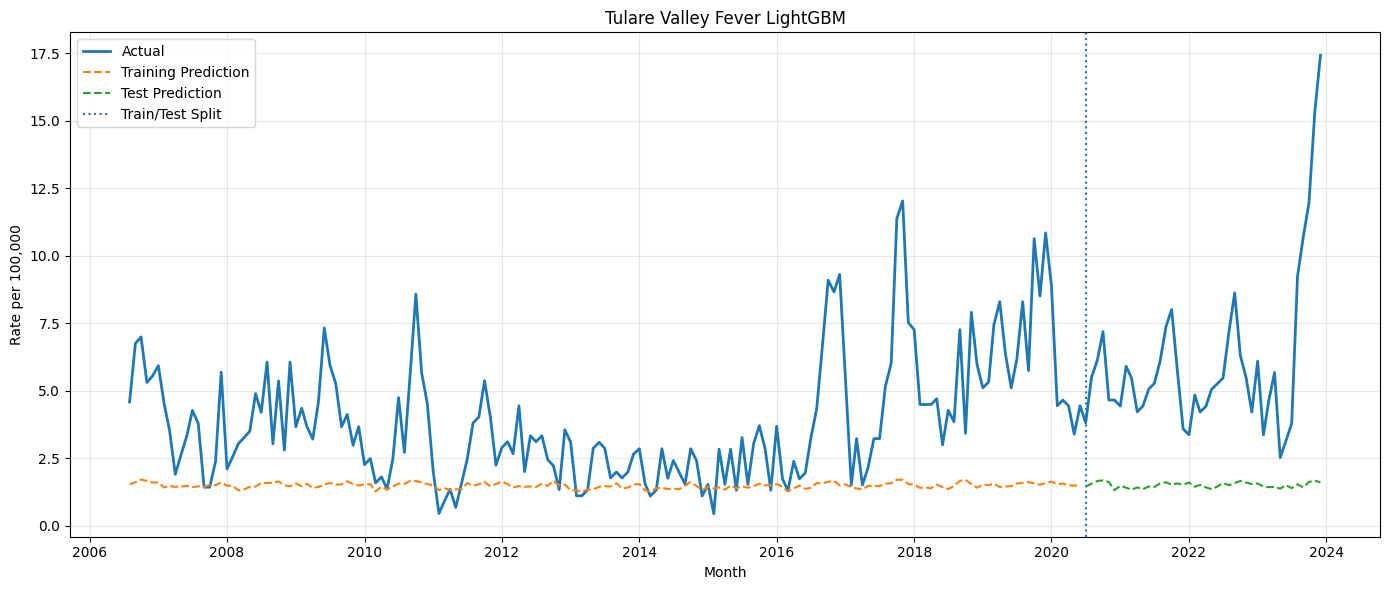


Running Ventura...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 0.66591	valid_0's l2: 0.443436
Training observations: 167
Test observations: 42
Best iteration: 1

Logged target metrics
Train RMSE: 0.4805
Train MAE:  0.3754
Train R²:   0.0142
Test RMSE:  0.6659
Test MAE:   0.5963
Test R²:    -3.8183

Original rate metrics
Train RMSE: 1.4796
Train MAE:  0.8237
Train R²:   -0.1264
Test RMSE:  2.1606
Test MAE:   1.8680
Test R²:    -2.9662


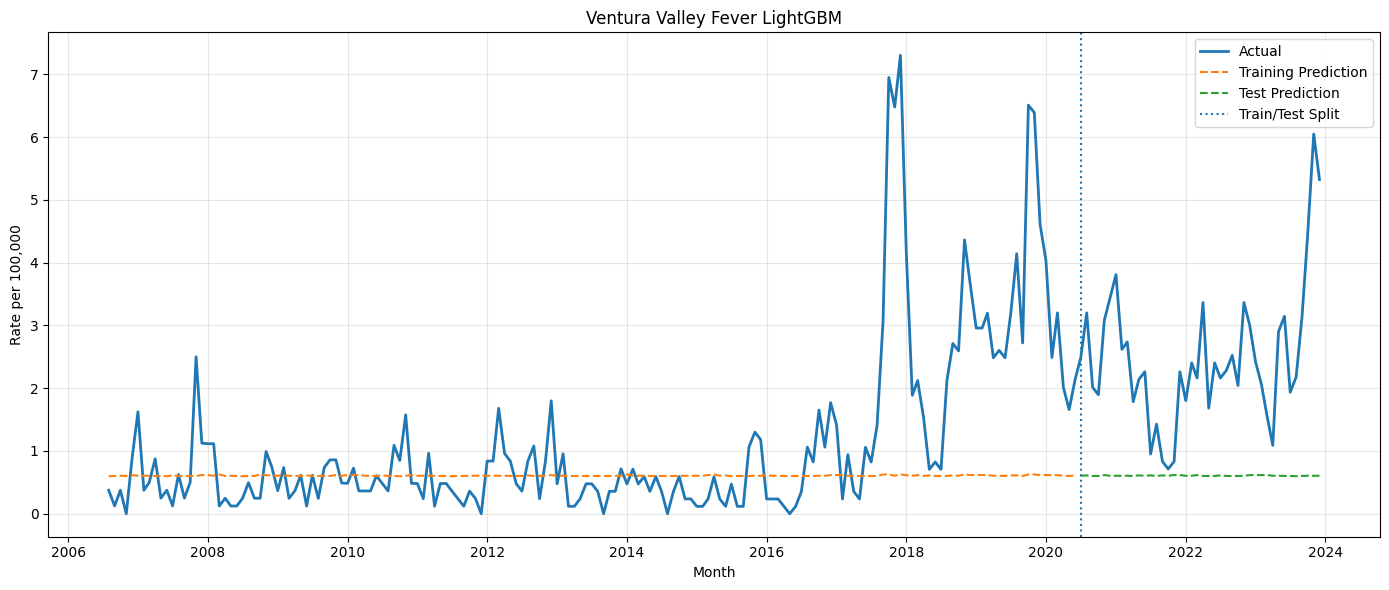

,County,Number_Features,Best_Iteration,Train_Log_RMSE,Test_Log_RMSE,Train_RMSE,Train_MAE,Train_R2,Test_RMSE,Test_MAE,Test_R2,Features
0,Orange,4,90,0.089969,0.194187,0.159717,0.112331,0.540067,0.392406,0.335749,-4.335112,"[windeventcount, Avg Soil Temp (F), FIRE_Acres..."
1,San Diego,4,141,0.121009,0.381382,0.256928,0.162970,0.345519,0.755000,0.713466,-12.460644,"[windeventcount, Avg Soil Temp (F), AQI_PM10, ..."
2,Los Angeles,3,1,0.187958,0.457764,0.302133,0.223469,-0.086570,0.887806,0.868988,-22.780186,"[Precipitation, Avg Wind Speed (mph), AQI_PM10]"
3,Ventura,3,1,0.480470,0.665910,1.479592,0.823697,-0.126450,2.160609,1.868046,-2.966184,"[Avg Rel Hum (%), AQI_PM10, FIRE_Acres_Burned]"
4,Fresno,5,4,0.458423,0.254164,3.988444,2.960646,-1.090437,2.747148,2.268510,-2.127189,"[Wind Run (miles), windeventcount, Avg Soil Te..."
5,Tulare,4,19,0.396888,0.500998,3.281560,2.445362,-1.027462,5.461462,4.588218,-2.304599,"[Precipitation, Avg Wind Speed (mph), windeven..."
6,San Luis Obispo,4,27,0.617328,0.451746,6.470518,3.770656,-0.362260,5.891152,3.920123,-0.747404,"[Avg Rel Hum (%), windeventcount, Avg Soil Tem..."
7,Kern,3,95,0.424251,0.425547,18.572994,15.162711,-1.897430,23.289997,22.124930,-9.025747,"[Avg Rel Hum (%), Avg Soil Temp (F), fungicide..."


In [14]:
all_county_lightgbm_results = {}
all_county_lightgbm_metrics = []

for county, feature_cols in features_by_county.items():
    print(f"\nRunning {county}...")

    county_df = (
        aggregated_data_trimmed[
            aggregated_data_trimmed["County"] == county
        ]
        .copy()
        .sort_values("Year-Month")
        .reset_index(drop=True)
    )

    county_results = train_lightgbm_forecast(
        df=county_df,
        feature_cols=feature_cols,
        target_col="log1p_rate_per_100k",
        original_target_col="rate_per_100k",
        date_col="Year-Month",
        train_frac=0.80,
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=15,
        max_depth=5,
        min_child_samples=8,
        subsample=0.9,
        colsample_bytree=1.0,
        reg_alpha=0.0,
        reg_lambda=0.1,
        seed=42,
        verbose=True,
        plot=True,
        title=f"{county} Valley Fever LightGBM"
    )

    all_county_lightgbm_results[county] = county_results

    all_county_lightgbm_metrics.append({
        "County": county,
        "Number_Features": len(feature_cols),
        "Best_Iteration": county_results["best_iteration"],
        "Train_Log_RMSE": county_results["train_log_rmse"],
        "Test_Log_RMSE": county_results["test_log_rmse"],
        "Train_RMSE": county_results["train_rmse"],
        "Train_MAE": county_results["train_mae"],
        "Train_R2": county_results["train_r2"],
        "Test_RMSE": county_results["rmse"],
        "Test_MAE": county_results["mae"],
        "Test_R2": county_results["r2"],
        "Features": feature_cols
    })

all_county_lightgbm_metrics_df = pd.DataFrame(
    all_county_lightgbm_metrics
)

display(
    all_county_lightgbm_metrics_df
    .sort_values("Test_RMSE")
    .reset_index(drop=True)
)

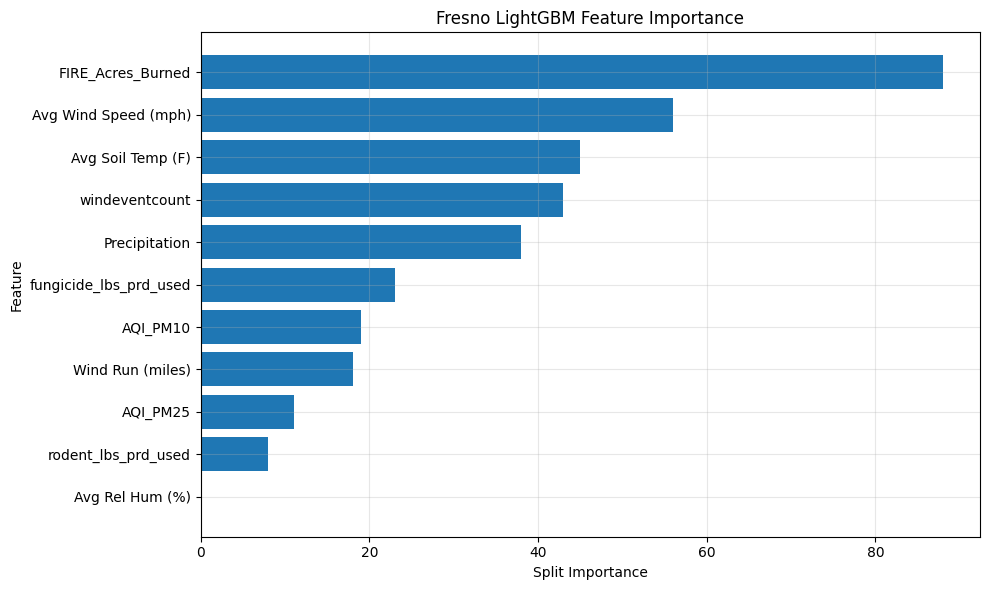

In [ ]:
county = "Fresno"

importance_df = (
    all_county_lightgbm_results[county]["feature_importance"]
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Split Importance")
plt.ylabel("Feature")
plt.title(f"{county} LightGBM Feature Importance")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
def lightgbm_grid_search(
        df,
        feature_cols,
        target_col="log1p_rate_per_100k",
        original_target_col="rate_per_100k",
        date_col="Year-Month",
        train_frac=0.80,
        n_splits=4,
        verbose=1
):
    model_df = df.copy().sort_values(date_col).reset_index(drop=True)

    required_cols = list(feature_cols) + [
        target_col,
        original_target_col,
        date_col
    ]

    model_df = model_df[required_cols].dropna().reset_index(drop=True)

    split = int(train_frac * len(model_df))

    if split <= 0 or split >= len(model_df):
        raise ValueError("The split must leave both training and test observations.")

    X = model_df[feature_cols]
    y = model_df[target_col]

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    test_dates = pd.to_datetime(model_df[date_col].iloc[split:])
    actual_test_rate = model_df[original_target_col].iloc[split:].to_numpy()

    base_model = LGBMRegressor(
        objective="regression",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    param_grid = {
        "n_estimators": [200, 500, 800],
        "learning_rate": [0.01, 0.03, 0.05],
        "num_leaves": [3, 7, 15],
        "max_depth": [2, 3, 5],
        "min_child_samples": [10, 20, 30],
        "subsample": [0.8, 1.0],
        "subsample_freq": [1],
        "colsample_bytree": [0.8, 1.0],
        "reg_alpha": [0.0, 0.1],
        "reg_lambda": [0.0, 0.1, 1.0]
    }

    time_series_cv = TimeSeriesSplit(n_splits=n_splits)

    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=time_series_cv,
        n_jobs=-1,
        verbose=verbose,
        refit=True,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    predicted_test_log = best_model.predict(X_test)
    predicted_test_rate = np.expm1(predicted_test_log)

    log_rmse = np.sqrt(mean_squared_error(y_test, predicted_test_log))
    log_mae = mean_absolute_error(y_test, predicted_test_log)
    log_r2 = r2_score(y_test, predicted_test_log)

    original_rmse = np.sqrt(
        mean_squared_error(
            actual_test_rate,
            predicted_test_rate
        )
    )

    original_mae = mean_absolute_error(
        actual_test_rate,
        predicted_test_rate
    )

    original_r2 = r2_score(
        actual_test_rate,
        predicted_test_rate
    )

    cv_results = pd.DataFrame(
        grid_search.cv_results_
    ).sort_values(
        "rank_test_score"
    ).reset_index(drop=True)

    test_results = pd.DataFrame({
        date_col: test_dates.to_numpy(),
        "Actual_Log1p_Rate": y_test.to_numpy(),
        "Predicted_Log1p_Rate": predicted_test_log,
        "Actual_Rate": actual_test_rate,
        "Predicted_Rate": predicted_test_rate
    })

    print("Best parameters:")
    print(grid_search.best_params__)

    print()
    print(
        "Best cross-validation RMSE:",
        -grid_search.best_score_
    )

    print()
    print("Final test metrics on log1p scale")
    print(f"RMSE: {log_rmse:.4f}")
    print(f"MAE:  {log_mae:.4f}")
    print(f"R²:   {log_r2:.4f}")

    print()
    print("Final test metrics on original scale")
    print(f"RMSE: {original_rmse:.4f}")
    print(f"MAE:  {original_mae:.4f}")
    print(f"R²:   {original_r2:.4f}")

    return {
        "grid_search": grid_search,
        "best_model": best_model,
        "best_params": grid_search.best_params_,
        "best_cv_rmse": -grid_search.best_score_,
        "cv_results": cv_results,
        "test_results": test_results,
        "log_rmse": log_rmse,
        "log_mae": log_mae,
        "log_r2": log_r2,
        "rmse": original_rmse,
        "mae": original_mae,
        "r2": original_r2,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

In [ ]:
fresno_df = (
    aggregated_data_trimmed[
        aggregated_data_trimmed["County"] == "Fresno"
    ]
    .copy()
    .sort_values("Year-Month")
    .reset_index(drop=True)
)

fresno_lightgbm_grid = lightgbm_grid_search(
    df=fresno_df,
    feature_cols=features_by_county["Fresno"],
    target_col="log1p_rate_per_100k",
    original_target_col="rate_per_100k",
    date_col="Year-Month",
    train_frac=0.80,
    n_splits=4,
    verbose=1
)

Fitting 4 folds for each of 5832 candidates, totalling 23328 fits


KeyboardInterrupt: 

# DONT CLOSE MY COMPUTER

In [ ]:
display(
    fresno_lightgbm_grid["cv_results"][
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "param_n_estimators",
            "param_learning_rate",
            "param_num_leaves",
            "param_max_depth",
            "param_min_child_samples",
            "param_subsample",
            "param_colsample_bytree",
            "param_reg_alpha",
            "param_reg_lambda"
        ]
    ].head(20)
)

In [ ]:
fresno_cv_results = fresno_lightgbm_grid["cv_results"].copy()

fresno_cv_results["Mean_CV_RMSE"] = (
    -fresno_cv_results["mean_test_score"]
)

fresno_cv_results["Train_CV_RMSE"] = (
    -fresno_cv_results["mean_train_score"]
)

display(
    fresno_cv_results[
        [
            "rank_test_score",
            "Mean_CV_RMSE",
            "std_test_score",
            "Train_CV_RMSE",
            "params"
        ]
    ].head(20)
)

In [ ]:
test_results = fresno_lightgbm_grid["test_results"]

plt.figure(figsize=(12, 5))

plt.plot(
    test_results["Year-Month"],
    test_results["Actual_Rate"],
    label="Actual",
    linewidth=2
)

plt.plot(
    test_results["Year-Month"],
    test_results["Predicted_Rate"],
    label="LightGBM Prediction",
    linestyle="--"
)

plt.title("Fresno LightGBM Grid-Search Model")
plt.xlabel("Month")
plt.ylabel("Rate per 100,000")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()